# 01 — Exploratory Data Analysis & Correlation
Scenario-stratified distribution analysis, correlation heatmaps (per SSP), and PCA.

**Run order:** This notebook expects `rawdata.csv` in the project root.  
Outputs → `data/processed/`


In [8]:
import warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_style("whitegrid")
os.makedirs("data/processed", exist_ok=True)
os.makedirs("figures", exist_ok=True)

print("Libraries loaded.")


Libraries loaded.


## 1. Load Data & Scenario Labels

In [9]:
df = pd.read_csv("rawdata.csv")
targets  = ["Leaf_TPC", "Root_TPC", "Leaf_TFC", "Root_TFC"]

def scenario_label(co2):
    """CO2 농도로 SSP 시나리오 레이블 부여 (01_preprocessing과 동일 기준)"""
    if co2 < 633:   return "SSP1-2.6"
    elif co2 < 961: return "SSP3-7.0"
    else:           return "SSP5-8.5"

if "scenario_group" not in df.columns:
    df["scenario_group"] = df["CO2ppm"].apply(scenario_label)

print("Shape:", df.shape)
print("Scenarios:", df["scenario_group"].value_counts().to_dict())
df.head()

Shape: (405, 26)
Scenarios: {'SSP5-8.5': 138, 'SSP1-2.6': 135, 'SSP3-7.0': 132}


,month,CO2ppm,Temp,Humid,VPD,Chl_a,Chl_b,TChl,Car,Chl_a_b,...,DF_abs,SFI_abs,Fv-Fm,Leaf_ExtractionYield,Root_ExtractionYield,Leaf_TPC,Root_TPC,Leaf_TFC,Root_TFC,scenario_group
0,5,381.681033,16.918639,83.130786,1.532512,8.79,2.22,11.00,2.97,3.97,...,0.328,0.215,0.830,19.0,18.9,7.476,6.270,5.217,0.861,SSP1-2.6
1,5,374.463441,16.922124,83.096722,1.532868,8.99,2.56,11.55,3.09,3.52,...,0.287,0.199,0.826,20.1,19.6,7.369,6.396,5.257,0.836,SSP1-2.6
2,5,371.850683,16.930256,82.488003,1.534584,9.66,2.44,12.10,3.11,3.96,...,0.384,0.229,0.828,20.7,20.4,7.369,6.396,5.242,0.841,SSP1-2.6
3,5,400.475202,16.921511,82.081632,1.534512,9.33,2.45,11.79,3.13,3.80,...,0.503,0.282,0.839,19.0,18.9,7.476,6.270,5.217,0.861,SSP1-2.6
4,5,381.360788,16.921323,83.888666,1.531475,10.53,2.58,13.11,3.37,4.08,...,0.304,0.203,0.832,20.1,19.6,7.369,6.396,5.257,0.836,SSP1-2.6


## 2. Missing Values & Outlier Check

In [10]:
# Missing values
miss = df.isna().sum()
print("=== Missing counts ===")
print(miss[miss > 0] if miss.any() else "No missing values.")

# IQR-based outlier count (factor 1.5)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
out_counts = {}
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    if n_out > 0:
        out_counts[col] = n_out

print("\n=== Outlier counts (IQR×1.5) ===")
pd.Series(out_counts).sort_values(ascending=False).head(15)

=== Missing counts ===
No missing values.

=== Outlier counts (IQR×1.5) ===


Fv-Fm                   67
DF_abs                  56
Root_TPC                45
Humid                   45
Root_ExtractionYield    45
Dio-RC                  38
PI_abs                  30
Chl_b                   24
Chl_a_b                 18
SFI_abs                 15
Temp                    15
VPD                     14
Tro-RC                  13
TCh-Car                 12
Eto-RC                  12
dtype: int64

## 3. Target Distribution by SSP Scenario

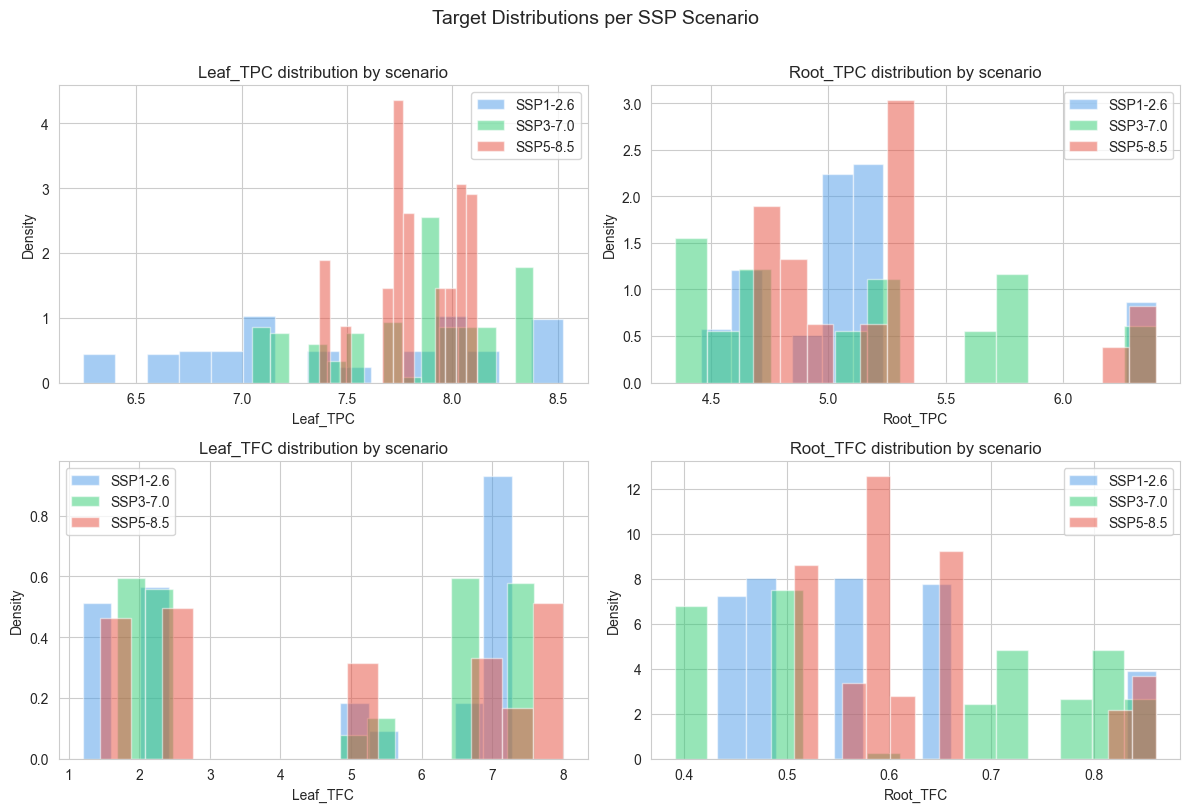

Saved → figures/target_distributions.png


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
palette = {"SSP1-2.6": "#4C9BE8", "SSP3-7.0": "#2ECC71", "SSP5-8.5": "#E74C3C"}

for i, tgt in enumerate(targets):
    for scen, grp in df.groupby("scenario_group"):
        axes[i].hist(grp[tgt].dropna(), alpha=0.5, bins=15,
                     label=scen, color=palette[scen], density=True)
    axes[i].set_title(f"{tgt} distribution by scenario")
    axes[i].set_xlabel(tgt); axes[i].set_ylabel("Density")
    axes[i].legend()

plt.suptitle("Target Distributions per SSP Scenario", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("figures/target_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/target_distributions.png")

## 4. Statistical Tests: ANOVA & Kruskal-Wallis

In [15]:
rows = []

for tgt in targets:
    g = [grp[tgt].dropna().values for _, grp in df.groupby("scenario_group")]
    f_stat, p_anova   = stats.f_oneway(*g)
    h_stat, p_kruskal = stats.kruskal(*g)
    rows.append({"target": tgt,
                 "ANOVA_F": round(f_stat, 3), "ANOVA_p": round(p_anova, 4),
                 "Kruskal_H": round(h_stat, 3), "Kruskal_p": round(p_kruskal, 4)})

stat_df = pd.DataFrame(rows)
print(stat_df.to_string(index=False))
stat_df.to_csv("data/processed/anova_kruskal_results.csv", index=False)

  target  ANOVA_F  ANOVA_p  Kruskal_H  Kruskal_p
Leaf_TPC   22.415   0.0000     17.934     0.0001
Root_TPC    1.463   0.2327     12.462     0.0020
Leaf_TFC    0.664   0.5153      6.369     0.0414
Root_TFC    7.576   0.0006     26.232     0.0000


## 5. Correlation Heatmaps per SSP Scenario

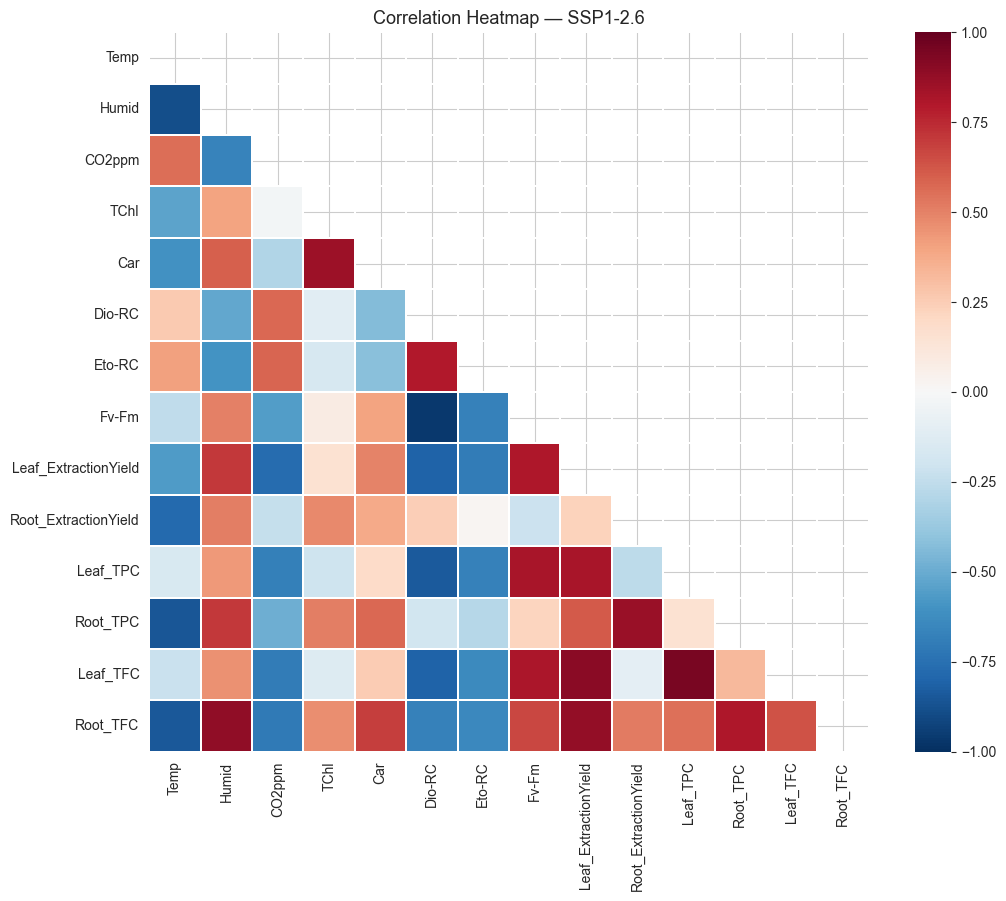

Saved → figures/correlation_SSP126.png


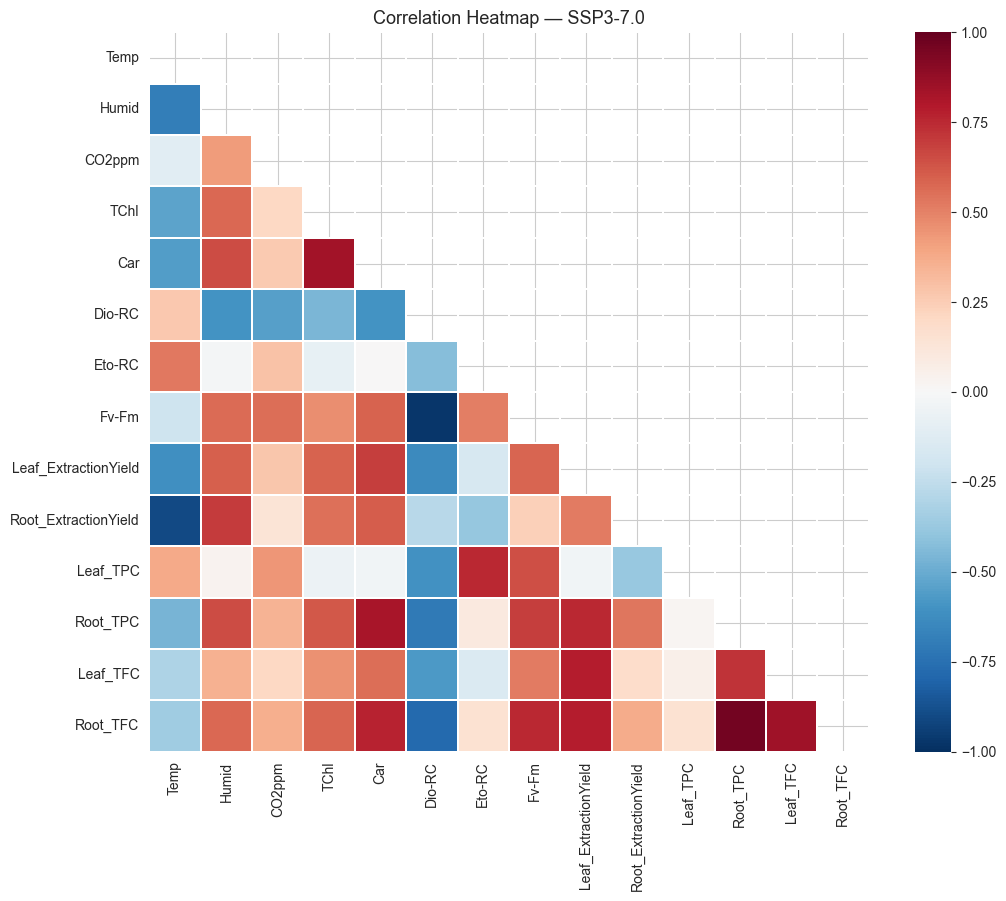

Saved → figures/correlation_SSP370.png


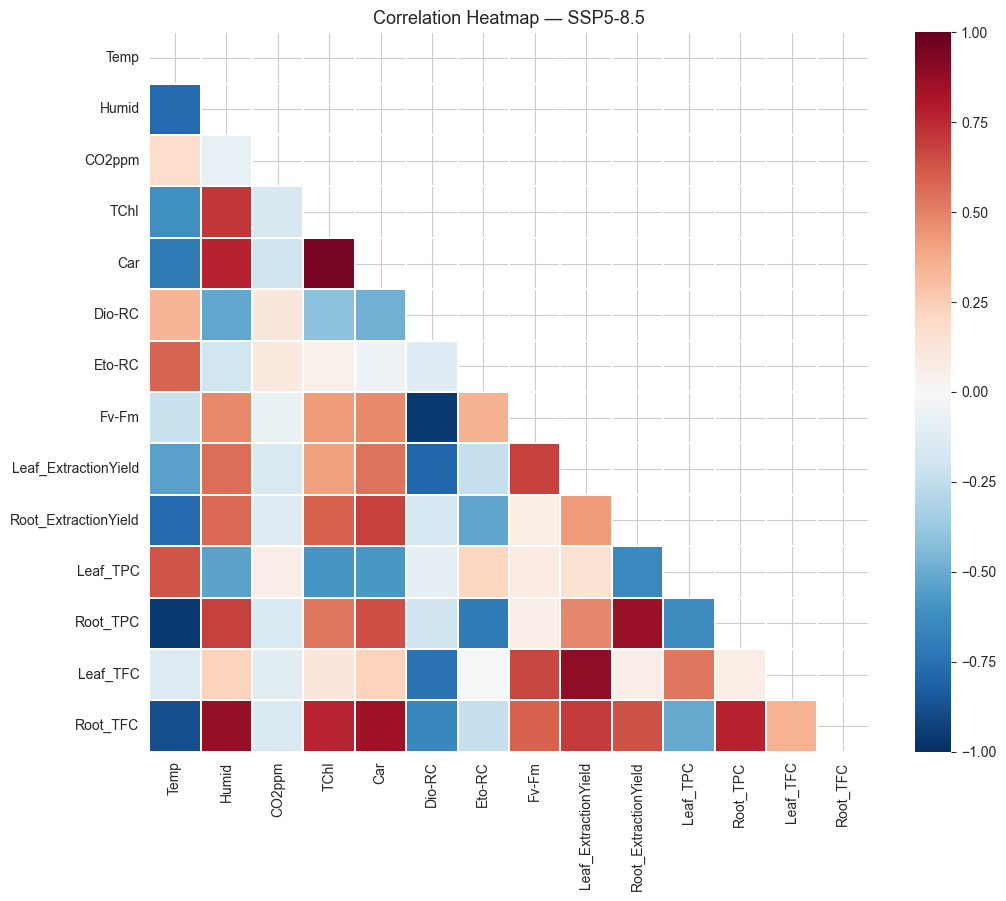

Saved → figures/correlation_SSP585.png


In [ ]:
feature_cols = [
    "Temp","Humid","CO2ppm","TChl","Car",
    "Dio-RC","Eto-RC","Fv-Fm",
    "Leaf_ExtractionYield","Root_ExtractionYield",
] + targets

for scen in ["SSP1-2.6", "SSP3-7.0", "SSP5-8.5"]:
    sub = df[df["scenario_group"] == scen][feature_cols].dropna()
    corr = sub.corr()

    plt.figure(figsize=(11, 9))
    mask = np.zeros_like(corr, dtype=bool)
    mask[np.triu_indices_from(mask)] = True
    sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, annot=False,
                linewidths=0.3, square=True)
    plt.title(f"Correlation Heatmap — {scen}", fontsize=13)
    plt.tight_layout()
    fname = f"figures/correlation_{scen.replace('-','').replace('.','')}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

## 6. PCA — Scenario Separation

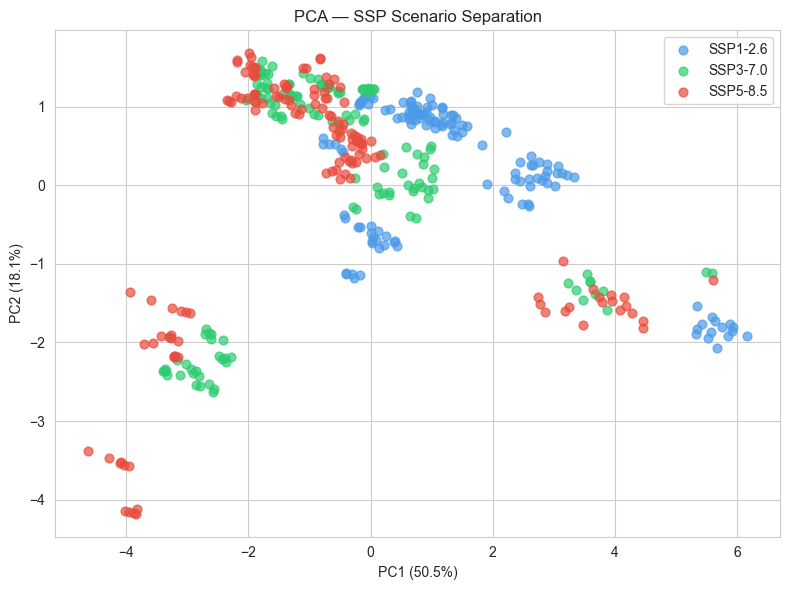

Top PC1 loadings:
Car                     0.394991
Humid                   0.380065
Temp                    0.375738
TChl                    0.359914
Leaf_ExtractionYield    0.335401
Dio-RC                  0.329932
Fv-Fm                   0.301727
Root_ExtractionYield    0.237747
dtype: float64


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pca_feats = [
    "Temp","Humid","CO2ppm","TChl","Car",
    "Dio-RC","Eto-RC","Fv-Fm",
    "Leaf_ExtractionYield","Root_ExtractionYield"
]
sub = df[pca_feats + ["scenario_group"]].dropna()
Xp  = StandardScaler().fit_transform(sub[pca_feats])
pca = PCA(n_components=2, random_state=42)
Xpc = pca.fit_transform(Xp)

pca_df = pd.DataFrame(Xpc, columns=["PC1","PC2"])
pca_df["scenario"] = sub["scenario_group"].values
colors = {"SSP1-2.6":"#4C9BE8","SSP3-7.0":"#2ECC71","SSP5-8.5":"#E74C3C"}

plt.figure(figsize=(8,6))
for scen, grp in pca_df.groupby("scenario"):
    plt.scatter(grp["PC1"], grp["PC2"], label=scen,
                alpha=0.7, s=40, color=colors[scen])
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA — SSP Scenario Separation")
plt.legend(); plt.tight_layout()
plt.savefig("figures/pca_scenario.png", dpi=150, bbox_inches="tight")
plt.show()

loadings = pd.Series(pca.components_[0], index=pca_feats).abs().sort_values(ascending=False)
print("Top PC1 loadings:")
print(loadings.head(8))

## 7. Top Correlations with Targets (per Scenario)

In [18]:
for scen in ["SSP1-2.6", "SSP3-7.0", "SSP5-8.5"]:
    sub = df[df["scenario_group"] == scen][feature_cols].dropna()
    corr_tgt = sub.corr()[targets].drop(targets, errors="ignore")
    print(f"\n=== {scen} — Top-8 correlations with each target ===")
    for tgt in targets:
        top = corr_tgt[tgt].abs().sort_values(ascending=False).head(8)
        print(f"  {tgt}: {dict(zip(top.index, top.values.round(3)))}")


=== SSP1-2.6 — Top-8 correlations with each target ===
  Leaf_TPC: {'Dio-RC': 0.836, 'Leaf_ExtractionYield': 0.824, 'Fv-Fm': 0.822, 'CO2ppm': 0.683, 'Eto-RC': 0.677, 'Humid': 0.436, 'Root_ExtractionYield': 0.263, 'TChl': 0.21}
  Root_TPC: {'Root_ExtractionYield': 0.867, 'Temp': 0.852, 'Humid': 0.705, 'Leaf_ExtractionYield': 0.616, 'Car': 0.573, 'TChl': 0.511, 'CO2ppm': 0.491, 'Eto-RC': 0.284}
  Leaf_TFC: {'Leaf_ExtractionYield': 0.899, 'Fv-Fm': 0.814, 'Dio-RC': 0.806, 'CO2ppm': 0.7, 'Eto-RC': 0.64, 'Humid': 0.456, 'Car': 0.253, 'Temp': 0.225}
  Root_TFC: {'Humid': 0.883, 'Leaf_ExtractionYield': 0.881, 'Temp': 0.848, 'CO2ppm': 0.71, 'Car': 0.691, 'Dio-RC': 0.674, 'Fv-Fm': 0.671, 'Eto-RC': 0.645}

=== SSP3-7.0 — Top-8 correlations with each target ===
  Leaf_TPC: {'Eto-RC': 0.752, 'Fv-Fm': 0.642, 'Dio-RC': 0.606, 'CO2ppm': 0.443, 'Temp': 0.383, 'Root_ExtractionYield': 0.38, 'TChl': 0.056, 'Car': 0.037}
  Root_TPC: {'Car': 0.827, 'Leaf_ExtractionYield': 0.75, 'Dio-RC': 0.709, 'Fv-Fm': 0.